# B1: Find The Spin-Lattice Relaxation Time $T_1$
### **Sub Objectives: Find the Spin-Lattice Relaxation Time $T_2$ of Proton, Find Larmor Frequency of Proton, and Find the Strength of the Ambient Magnetic Field $B_0$**

## Overall TODO:
Add error analysis
- How do I get an error on the FFT I perform to get the Larmour Frequency from my data?
- How do I estimate the time errors?
- Make plot fonts larger

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd
from pathlib import Path
from helper import *

In [35]:
# CONFIG
data_dir_path = "/B1 Data/" # Change this between notebooks

TEST_DIR = False

csv_dict = {
"30": ["T0030.CSV", "T0031.CSV", "T0032.CSV"],
"13": ["T0001.CSV", "T0002.CSV", "T0003.CSV"],
"12": ["T0004.CSV", "T0005.CSV", "T0006.CSV"],
"11": ["T0007.CSV", "T0008.CSV", "T0009.CSV"],
"5": ["T0010.CSV", "T0011.CSV", "T0012.CSV"],
"4": ["T0013.CSV", "T0014.CSV", "T0015.CSV"],
"3": ["T0016.CSV", "T0017.CSV", "T0018.CSV"],
"2": ["T0019.CSV", "T0020.CSV", "T0021.CSV"],
"1": ["T0022.CSV", "T0023.CSV", "T0024.CSV"],
"0.5": ["T0025.CSV", "T0026.CSV", "T0027.CSV"],
}

In [36]:
# DIR CONFIG
base_dir_path = str(Path.cwd())
DATA_DIR = base_dir_path + data_dir_path

if TEST_DIR == True:
    print("Test Path: ", DATA_DIR + "T0001.CSV")
    df = pd.read_csv(DATA_DIR + "T0001.CSV", skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
    print("Data frame loaded!")

Look at a singular csv file.

In [37]:
test_csv = "T0008.CSV"
df_test = pd.read_csv(DATA_DIR + test_csv, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
df_test = df_test.apply(pd.to_numeric, errors='coerce') # Foce data types from strings to numbers

# Look at the df
x = df_test["CH1"].to_numpy()
y = df_test["CH2"].to_numpy()
t = df_test["TIME"].to_numpy()

# Verify
print(df_test.dtypes)
print(df_test.head())

TIME               float64
CH1                float64
CH1 Peak Detect    float64
CH2                float64
CH2 Peak Detect    float64
dtype: object
       TIME           CH1  CH1 Peak Detect           CH2  CH2 Peak Detect
0       NaN           NaN              NaN           NaN              NaN
1 -0.775200  3.814700e-09            0.008  8.000010e-03            0.016
2 -0.775168 -8.000000e-03           -0.008  5.722050e-09           -0.008
3 -0.775136  3.814700e-09            0.008  5.722050e-09            0.016
4 -0.775104  3.814700e-09           -0.008  5.722050e-09           -0.008


In [38]:
# Find index where t = 0
idx = find_closest_index(df_test, column_name = 'TIME')
print(f"The index closest to 0 is: {idx}")

The index closest to 0 is: 24226


Plot both channels.

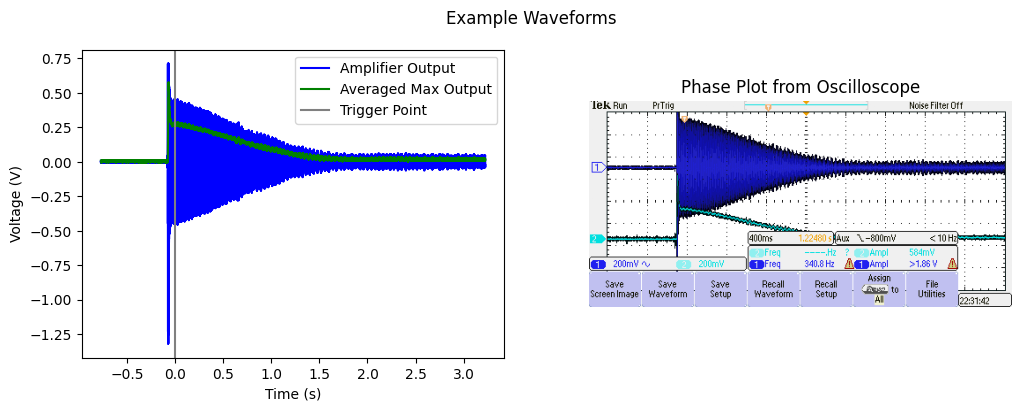

In [39]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Example Waveforms')

# Plot CSV Data on ax1

# Plot CH1 (Signal)
ax1.plot(t, x, label='Amplifier Output', 
                    color='blue')
# Plot CH2 (Averaged Max)
ax1.plot(t, y, label='Averaged Max Output', 
                    color='green')
# Plot Trigger Point
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")
ax1.legend()

# Plot Image on ax2
img = plt.imread(DATA_DIR + "T0008.png")
ax2.imshow(img)
ax2.set_title("Phase Plot from Oscilloscope")
ax2.axis('off')

plt.show()

### Estimate Uncertainties: Thickness of Trace

Text(0.5, 0, 'Time (s)')

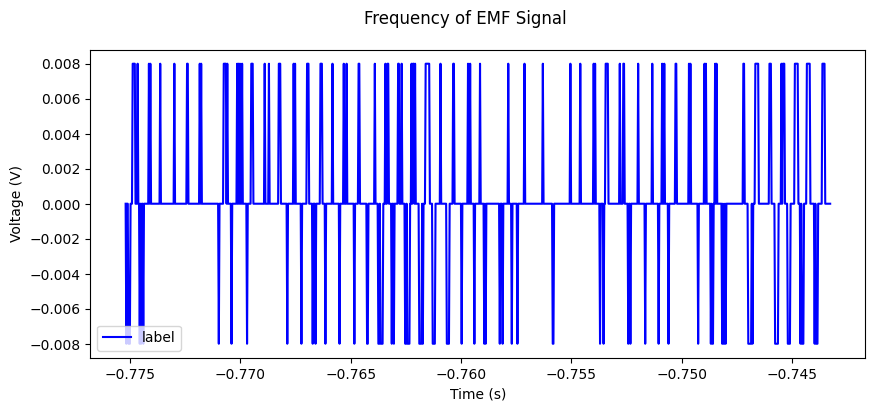

In [40]:
end = 1000

# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

ax1.plot(t[:end], x[:end], label='label', 
                    color='blue')
# ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.legend()
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

According to the beginging section of the plot, before any signal goes through, there is a thickness of trace of **0.016**.

Look at the waveform and find the Larmor Frequency.

In [41]:
start = idx # Set start index at trigger point
end = start + 1000 # Set end index

t_subset = t[start:end]
x_subset = x[start:end]

# For initial guess, do FFT
y_fft = np.fft.rfft(x_subset)
# print(y_fft)
y_fft = np.fft.rfft(x_subset)
freqs = np.fft.rfftfreq(len(t_subset), d=(t_subset[1] - t_subset[0]))
fft_frequency = freqs[np.argmax(np.abs(y_fft))]
print(f"Fast Fourier Transform Frequency: {fft_frequency:.2f} Hz")


# Fit to a sine model
freq = fft_frequency * 2 * np.pi # TODO: Figure out why this needs to be multiplied by 2pi
def sine_fcn(B, x):
    return B[0] * np.sin(freq * x + B[1])
sine_model = odr.Model(sine_fcn)

mydata = odr.RealData(t_subset, x_subset)

sol = odr.ODR(mydata, sine_model, beta0=[0.4, 0])
myoutput = sol.run()
# myoutput.pprint()

Fast Fourier Transform Frequency: 1656.25 Hz


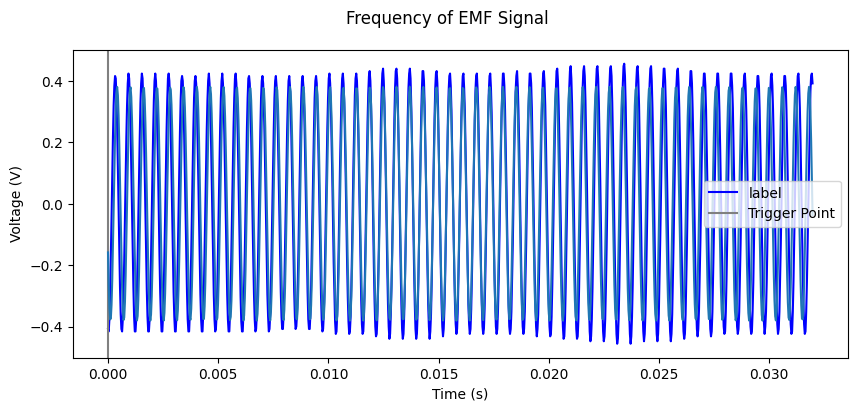

In [42]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

ax1.plot(t[start:end], x[start:end], label='label', 
                    color='blue')
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.legend()
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

# Plot fitted sine wave
fitted_x = sine_fcn(myoutput.beta, t_subset)
ax1.plot(t_subset, fitted_x)

Looking at this, we can just pull frequency from CH1!

Eventually, we will want to fit this data to find the Larmour Frequency. Can I use this fit to approximate the thickness of the trace to estimate errors?

In [43]:
(ch1, ch2) = max_at_trigger(df_test)

In [44]:
total_points = []
avg_points = []
std_points = []

for m_time, paths in csv_dict.items():
    # Look at each of the three CSV's
    CH2_points = []
    for i in range(3):
        single_csv_path = paths[i]
        csv_path = DATA_DIR + single_csv_path

        # Read csv
        df = pd.read_csv(csv_path, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])

        # Foce data types from strings to numbers
        df = df.apply(pd.to_numeric, errors='coerce')

        # Get CH2 value
        (CH1, CH2) = max_at_trigger(df)

        # Add CH2 value to plotting points
        total_points.append((m_time, CH2))

        CH2_points.append(CH2)

    # Save std and average
    std_points.append((m_time, np.std(CH2_points)))
    avg_points.append((m_time, np.mean(CH2_points)))
    pass

In [45]:
# Use standard deviation to estimate uncertainty
y_uncerts = []
print("Time, STD, STD with Trace")
for time, std in std_points:
    error_quad = np.sqrt(.008**2 + std**2)
    y_uncerts.append(error_quad)
    print(time, std**2, error_quad)

# Add the errors in quadriature

Time, STD, STD with Trace
30 1.4222222222222246e-05 0.008844332774281068
13 0.0 0.008
12 0.0 0.008
11 4.2666666666666446e-05 0.010327955589886435
5 0.0 0.008
4 1.4222222222222246e-05 0.008844332774281068
3 1.4222222222222246e-05 0.008844332774281068
2 0.0 0.008
1 5.6888888888888895e-05 0.010994948334980428
0.5 0.0 0.008


It looks like the standard deviation of the amplitude at the trigger points is much smaller than the uncertainty due to trace thickness. We will add the errors in quadriature.

In [51]:
# Unpack data_points
x_vals = []
y_vals = []
for tuple in avg_points:
    time = eval(tuple[0])
    voltage = tuple[1]
    x_vals.append(time)
    y_vals.append(voltage)

# Turn into nparrays
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)

In [52]:
# Fit

# Use t=13 point as M0
M_0 = y_vals[1]
print(f"M_0: {M_0}")

# Plot ln(M_0) = ln(M_0 - M(t)) + 1/T_1 t
def test_fcn(B, x): # B[0] = T_1, B[1] = M_0
    return M_0 * (1-np.exp(-1 * x / B[0]))
model = odr.Model(test_fcn)

mydata = odr.RealData(x_vals, y_vals, sy = y_uncerts)

sol = odr.ODR(mydata, model, beta0=[9.])
myoutput = sol.run()
myoutput.pprint()

M_0: 0.288
Beta: [2.92497649]
Beta Std Error: [0.10628448]
Beta Covariance: [[0.14192965]]
Residual Variance: 0.0795914832729197
Inverse Condition #: 1.0
Reason(s) for Halting:
  Sum of squares convergence


In [53]:
print(type(x_vals))

<class 'numpy.ndarray'>


<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_10576/2601939595.py:24: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"


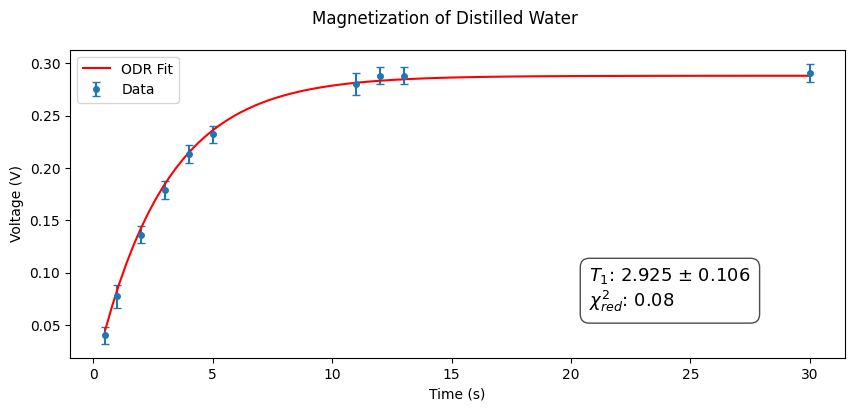

In [61]:
# Generate fit curve
x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
y_fit = test_fcn(myoutput.beta, x_fit)

fig3, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig3.suptitle("Magnetization of Distilled Water")
# ax1.scatter(x_vals, y_vals, label='Data', color='blue')
plt.errorbar(x_vals, y_vals, 
             # xerr=x_uncerts, 
             yerr=y_uncerts,
             fmt='o', label='Data', capsize=3, markersize=4)

ax1.plot(x_fit, y_fit, color='red', label='ODR Fit')
ax1.legend()

# TODO: Insert Fit Details
T_1 = myoutput.beta[0]
T_1_error = myoutput.sd_beta[0]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"$T_1$: {T_1:.3f} ± {T_1_error:.3f}\n"
    # f"$\chi^2$: {chi_sq:.3f}\n"
    f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"
)
plt.text(0.67, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=13, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

plt.show()